# Module 6 Exercises

## Ryan Waterman
## 8/13/2025

# Lab Exercises

## Chapter 8.3.1

In [82]:
#Imports

import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from statsmodels.datasets import get_rdataset
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS
from sklearn.tree import (DecisionTreeClassifier as DTC,
DecisionTreeRegressor as DTR,
plot_tree,
export_text)
from sklearn.metrics import (accuracy_score,
log_loss)
from sklearn.ensemble import \
(RandomForestRegressor as RF,
GradientBoostingRegressor as GBR)
from ISLP.bart import BART

## Car Seat Data Set Information

A simulated data set containing sales of child car seats at 400 different stores.

Sales: Unit sales (in thousands) at each location

CompPrice: Price charged by competitor at each location

Income: Community income level (in thousands of dollars)

Advertising: Local advertising budget for company at each location (in thousands of dollars)

Population: Population size in region (in thousands)

Price: Price company charges for car seats at each site

ShelveLoc: A factor with levels Bad, Good and Medium indicating the quality of the shelving location for the car seats at each site

Age: Average age of the local population

Education: Education level at each location

Urban: A factor with levels No and Yes to indicate whether the store is in an urban or rural location

US: A factor with levels No and Yes to indicate whether the store is in the US or not

In [83]:
"""
First, recode the carseat sales data into a binary yes or no for sales > 8
"""

Carseats = load_data('Carseats')
High = np.where(Carseats.Sales > 8,
                "Yes",
                "No")

In [84]:
"""
Use a Decision Tree Classifier to fit a classification tree to predict High using all variables except Sales.
"""

model = MS(Carseats.columns.drop('Sales'), intercept=False)
D = model.fit_transform(Carseats) 
feature_names = list(D.columns)
X = np.asarray(D)

In [85]:
"""
Select cross-entropy as the split criterion, as well as a max depth to grow the tree and random state for reproducability.
"""

clf = DTC(criterion='entropy',
max_depth=3,
random_state=0)
clf.fit(X, High)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
"""
Use the accuracy_score function to compute the prediction accuracy of the model on the data.
"""

accuracy_score(High, clf.predict(X))

0.79

In [87]:
"""
Get the deviance for the classification tree using the log loss function. 

The log loss value is to be minimized as an indicator that the model fits the data well.
"""

resid_dev = np.sum(log_loss(High, clf.predict_proba(X)))
resid_dev

np.float64(0.47106470626493574)

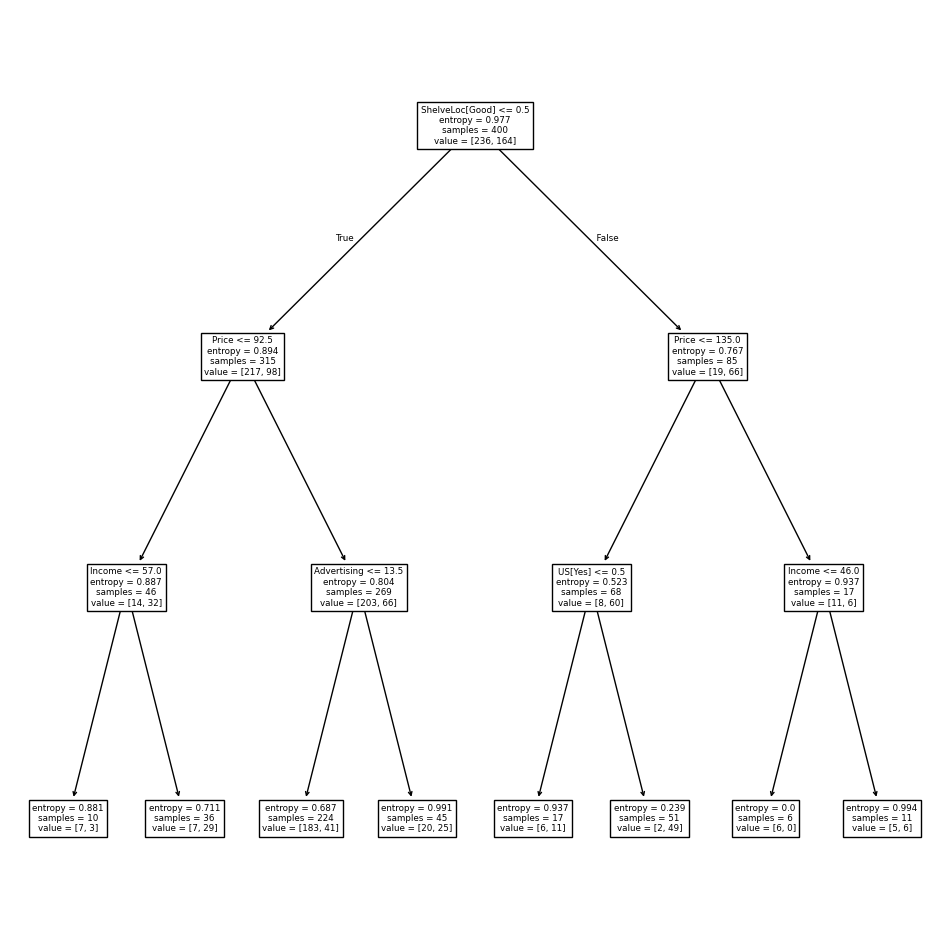

In [88]:
"""
Display the tree graphically.
"""
ax = subplots(figsize=(12,12))[1]
plot_tree(clf,
feature_names=feature_names,
ax=ax);

In [89]:
"""
Print the branch and leaf nodes
"""

print(export_text(clf,
feature_names=feature_names,
show_weights=True))

|--- ShelveLoc[Good] <= 0.50
|   |--- Price <= 92.50
|   |   |--- Income <= 57.00
|   |   |   |--- weights: [7.00, 3.00] class: No
|   |   |--- Income >  57.00
|   |   |   |--- weights: [7.00, 29.00] class: Yes
|   |--- Price >  92.50
|   |   |--- Advertising <= 13.50
|   |   |   |--- weights: [183.00, 41.00] class: No
|   |   |--- Advertising >  13.50
|   |   |   |--- weights: [20.00, 25.00] class: Yes
|--- ShelveLoc[Good] >  0.50
|   |--- Price <= 135.00
|   |   |--- US[Yes] <= 0.50
|   |   |   |--- weights: [6.00, 11.00] class: Yes
|   |   |--- US[Yes] >  0.50
|   |   |   |--- weights: [2.00, 49.00] class: Yes
|   |--- Price >  135.00
|   |   |--- Income <= 46.00
|   |   |   |--- weights: [6.00, 0.00] class: No
|   |   |--- Income >  46.00
|   |   |   |--- weights: [5.00, 6.00] class: Yes



In [90]:
"""
Estimate the test error of the tree to evaluate it's performance.
"""

validation = skm.ShuffleSplit(n_splits=1,
                            test_size=200,
                            random_state=0)

results = skm.cross_validate(clf,
                            D,
                            High,
                            cv=validation)
results['test_score']

array([0.685])

In [91]:
"""
Consider tree pruning as a possibilty for improving classification performance.
"""

(X_train,
X_test,
High_train,
High_test) = skm.train_test_split(X,
                                High,
                                test_size=0.5,
                                random_state=0)

In [92]:
"""
Refit the full tree to the training set without setting a max_depth parameter.
"""

clf = DTC(criterion='entropy', random_state=0) 
clf.fit(X_train, High_train)
accuracy_score(High_test, clf.predict(X_test))

0.735

In [93]:
"""
Extract the cost-complexity values. 
"""

ccp_path = clf.cost_complexity_pruning_path(X_train, High_train)
kfold = skm.KFold(10,
random_state=1,
shuffle=True)

In [94]:
"""
Extract the optimal alpha value using cross-validation.
"""

grid = skm.GridSearchCV(clf,
                        {'ccp_alpha': ccp_path.ccp_alphas}, 
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X_train, High_train)
grid.best_score_

np.float64(0.685)

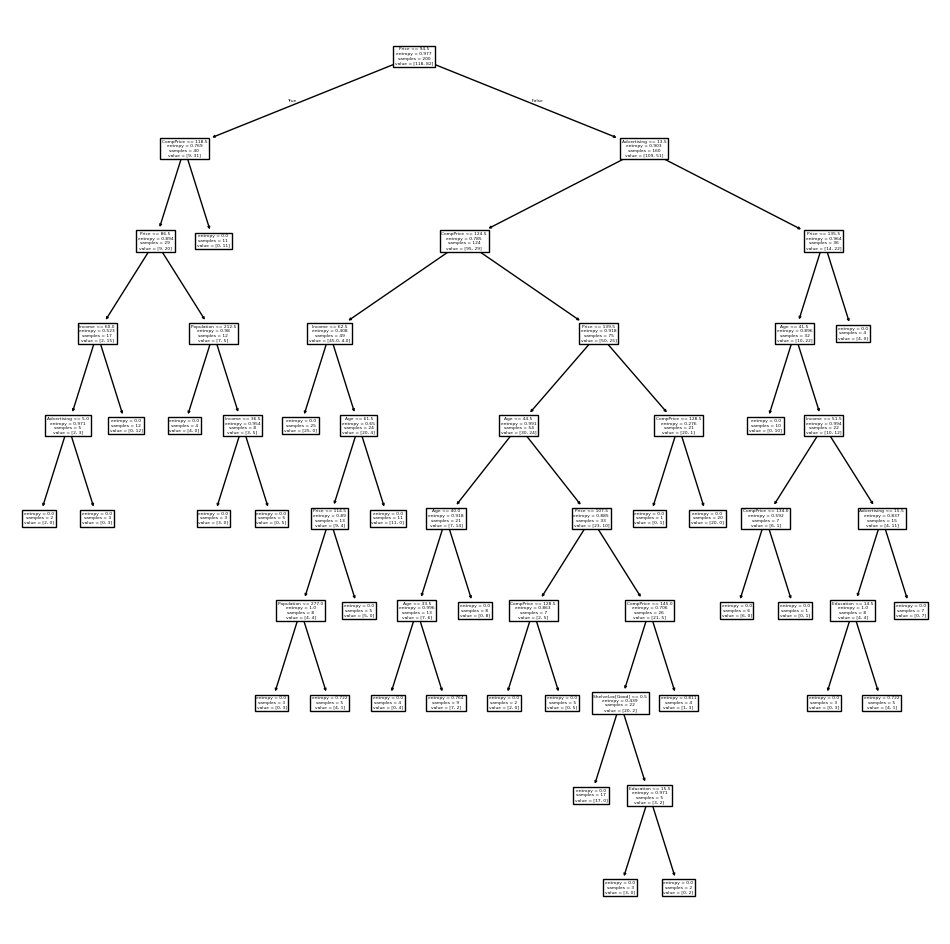

In [95]:
"""
Look at the pruned tree.
"""

ax = subplots(figsize=(12, 12))[1]
best_ = grid.best_estimator_
plot_tree(best_,
feature_names=feature_names,
ax=ax);

In [96]:
"""
Count the number of leaves on the tree.
"""

best_.tree_.n_leaves

np.int64(30)

In [97]:
"""
Test the performance of the pruned tree on the test dataset.
"""

print(accuracy_score(High_test,
best_.predict(X_test)))
confusion = confusion_table(best_.predict(X_test),
High_test)
confusion

0.72


Truth,No,Yes
Predicted,,
No,94,32
Yes,24,50


## Chapter 8.3.2

## Boston Data Set Information

A data set containing housing values in 506 suburbs of Boston.

crim: per capita crime rate by town.

zn: proportion of residential land zoned for lots over 25,000 sq.ft.

indus: proportion of non-retail business acres per town.

chas: Charles River dummy variable (= 1 if tract bounds river; 0 otherwise).

nox: nitrogen oxides concentration (parts per 10 million).

rm: average number of rooms per dwelling.

age: proportion of owner-occupied units built prior to 1940.

dis: weighted mean of distances to five Boston employment centres.

rad: index of accessibility to radial highways.

tax: full-value property-tax rate per $10,000.

ptratio: pupil-teacher ratio by town.

lstat: lower status of the population (percent).

medv: median value of owner-occupied homes in $1000s.

In [98]:
Boston = load_data("Boston")
model = MS(Boston.columns.drop('medv'), intercept=False)
D = model.fit_transform(Boston) 
feature_names = list(D.columns)
X = np.asarray(D)

In [99]:
(X_train,
X_test,
y_train,
y_test) = skm.train_test_split(X,
Boston['medv'],
test_size=0.3,
random_state=0)

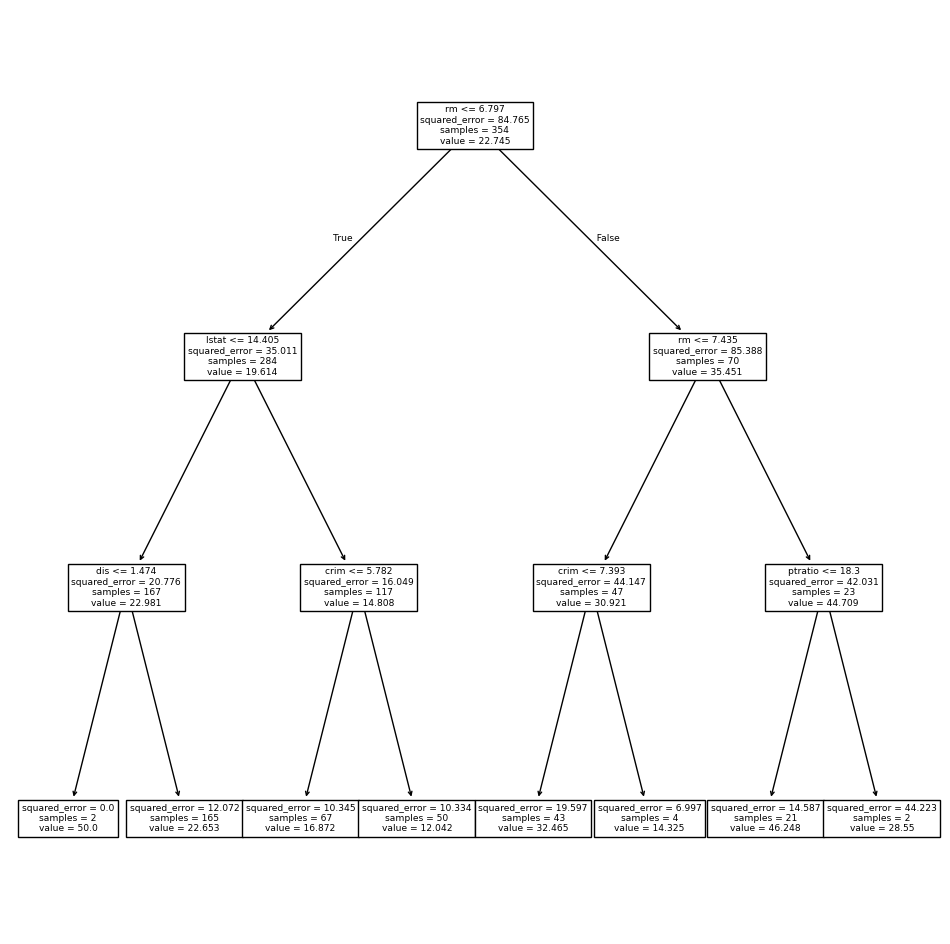

In [100]:
reg = DTR(max_depth=3)
reg.fit(X_train, y_train)
ax = subplots(figsize=(12,12))[1]
plot_tree(reg,
feature_names=feature_names,
ax=ax);

In [101]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5,
shuffle=True,
random_state=10)
grid = skm.GridSearchCV(reg,
{'ccp_alpha': ccp_path.ccp_alphas}, 
refit=True,
cv=kfold,
scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train) 

In [102]:
best_ = grid.best_estimator_
np.mean((y_test - best_.predict(X_test))**2)

np.float64(28.06985754975404)

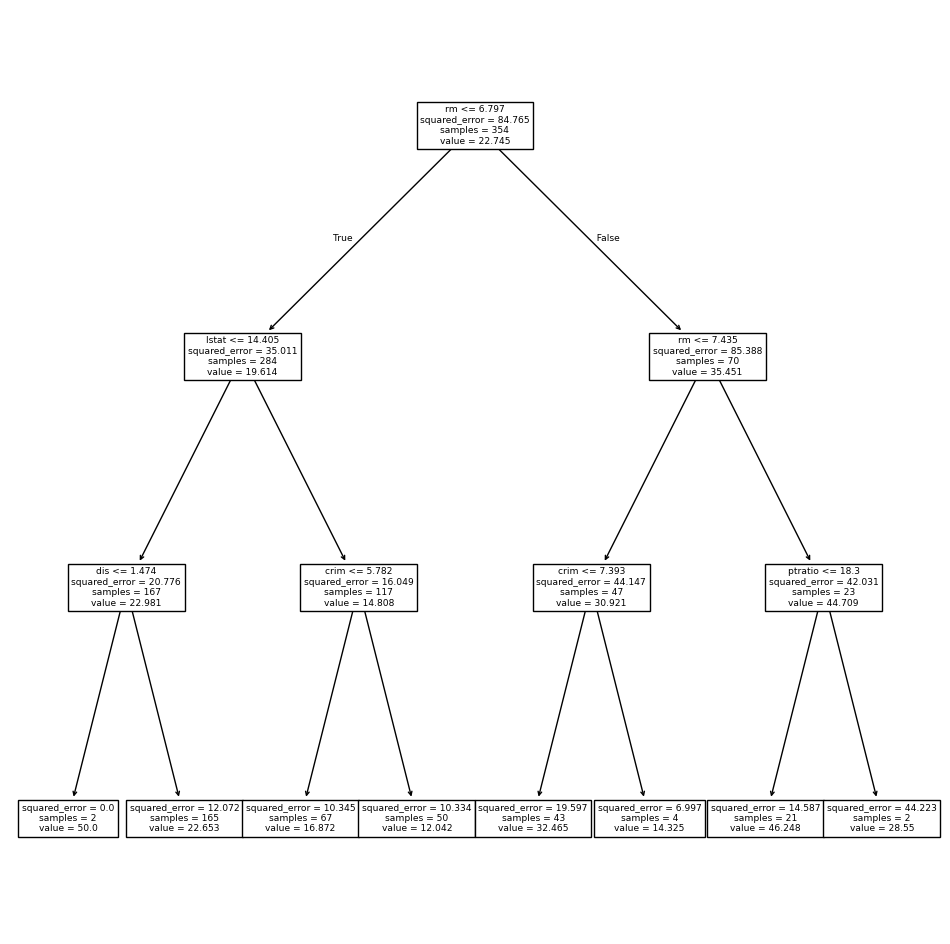

In [103]:
ax = subplots(figsize=(12,12))[1]
plot_tree(G.best_estimator_,
feature_names=feature_names,
ax=ax);

## Chapter 8.3.3

In [104]:
bag_boston = RF(max_features=X_train.shape[1], random_state=0)
bag_boston.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,12
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


np.float64(14.634700151315787)

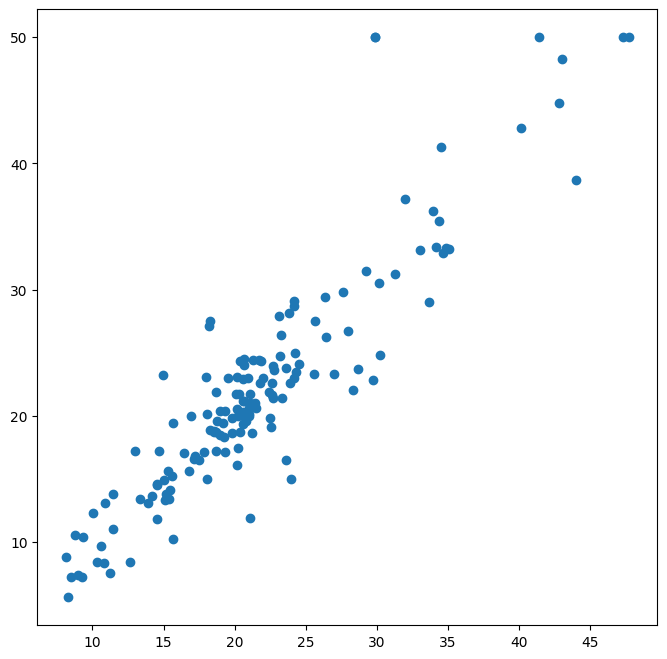

In [105]:
ax = subplots(figsize=(8,8))[1]
y_hat_bag = bag_boston.predict(X_test)
ax.scatter(y_hat_bag, y_test)
np.mean((y_test - y_hat_bag)**2)

In [106]:
bag_boston = RF(max_features=X_train.shape[1],
n_estimators=500,
random_state=0).fit(X_train, y_train)
y_hat_bag = bag_boston.predict(X_test)
np.mean((y_test - y_hat_bag)**2)

np.float64(14.605662565263161)

In [107]:
RF_boston = RF(max_features=6,
random_state=0).fit(X_train, y_train)
y_hat_RF = RF_boston.predict(X_test)
np.mean((y_test - y_hat_RF)**2)

np.float64(20.04276446710527)

In [108]:
feature_imp = pd.DataFrame(
{'importance':RF_boston.feature_importances_},
index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
lstat,0.356203
rm,0.332163
ptratio,0.067270
crim,0.055404
indus,0.053851
dis,0.041582
nox,0.035225
tax,0.025355
age,0.021506
rad,0.004784


# Problem 9 Parts A-F

This problem involves the OJ data set which is part of the ISLP package.

## OJ Data Set Description

Purchase: A factor with levels ‘CH’ and ‘MM’ indicating whether the customer purchased Citrus Hill or Minute Maid Orange Juice

WeekofPurchase: Week of purchase

StoreID: Store ID

PriceCH: Price charged for CH

PriceMM: Price charged for MM

DiscCH: Discount offered for CH

DiscMM: Discount offered for MM

SpecialCH: Indicator of special on CH

SpecialMM: Indicator of special on MM

LoyalCH: Customer brand loyalty for CH

SalePriceMM: Sale price for MM

SalePriceCH: Sale price for CH

PriceDiff: Sale price of MM less sale price of CH

Store7: A factor with levels ‘No’ and ‘Yes’ indicating whether the sale is at Store 7

PctDiscMM: Percentage discount for MM

PctDiscCH: Percentage discount for CH

ListPriceDiff: List price of MM less list price of CH

STORE: Which of 5 possible stores the sale occured at

## Part A

Create a training set containing a random sample of 800 observations, and a test set containing the remaining observations.

In [109]:
oj = load_data('OJ')

In [110]:
from random import randint, seed

In [111]:
def split_data(data, train_count):
    seed(42)
    data_indices = list(data.index.values)
    train_indices = []

    for i in range(train_count):
        rand_idx = randint(1,len(data_indices))
        train_indices.append(data_indices[rand_idx])
        data_indices.remove(data_indices[rand_idx])

    training_data = data.iloc[train_indices]
    test_data = data.iloc[data_indices]
    
    return training_data, test_data

In [112]:
training_data, test_data = split_data(oj, 800) 

print(len(training_data), len(test_data))

800 270


In [113]:
training_data.head(5)

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,Store7,PctDiscMM,PctDiscCH,ListPriceDiff,STORE
229,CH,274,7,1.86,2.13,0.47,0.54,1,0,0.520000,1.59,1.39,0.20,Yes,0.253521,0.252688,0.27,0
52,CH,252,4,1.99,2.23,0.00,0.00,0,0,0.793712,2.23,1.99,0.24,No,0.000000,0.000000,0.24,4
566,MM,233,7,1.75,1.99,0.00,0.40,1,0,0.400000,1.59,1.75,-0.16,Yes,0.201005,0.000000,0.24,0
504,CH,244,3,1.99,2.23,0.00,0.00,0,0,0.754240,2.23,1.99,0.24,No,0.000000,0.000000,0.24,3
460,MM,246,2,1.89,2.09,0.00,0.00,0,0,0.480000,2.09,1.89,0.20,No,0.000000,0.000000,0.20,2


**I had to modify my existing random split function to take a number of training rows instead of a percentage, but the random selection process is fundamentally the same.**

## Part B

Fit a tree to the training data, with Purchase as the response and the other variables as predictors. What is the training error rate?

In [114]:
model = MS(training_data.columns.drop('Purchase'), intercept=False)
D = model.fit_transform(training_data) 
feature_names = list(D.columns)
X_train = np.asarray(D)
Y_train = training_data['Purchase']

In [115]:
clf = DTC(criterion='entropy',
max_depth=10,
random_state=0)
clf.fit(X_train, Y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [116]:
accuracy_score(Y_train, clf.predict(X_train))

0.94625

**A training error rate of 94.625% is high for an unoptimized decision tree, but I suspect that is a result of the max_depth parameter being set to 10. This allows the decision tree to grow too large and over-fit to the training data. I suspect the test accuracy will be lower.**

## Part C

Create a plot of the tree, and interpret the results. How many terminal nodes does the tree have?

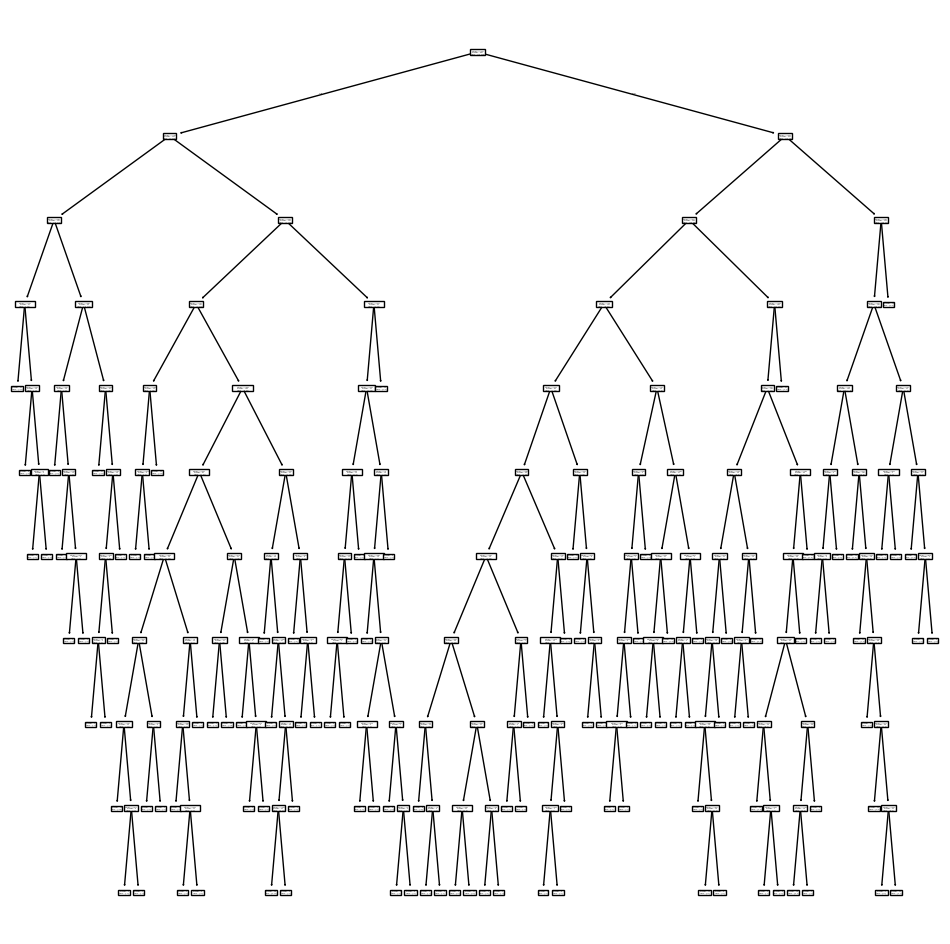

In [117]:
"""
Display the tree graphically.
"""
ax = subplots(figsize=(12,12))[1]
plot_tree(clf,
feature_names=feature_names,
ax=ax);

In [118]:
clf.tree_.n_leaves

np.int64(112)

**As I commented on before, this tree grew quite large, having 112 terminal nodes as a result of a depth parameter of 10. This allows the tree to bifricate many times, leading to decision points that allow the tree to overfit to the training data.**

## Part D

Use the export_tree() function to produce a text summary of the fitted tree. Pick one of the terminal nodes, and interpret the information displayed.

### **NOTE: I AM HIDING THE OUTPUT OF THE CODE BLOCK, BELOW, AS IT IS NEARLY 3 PAGES IN THE OUTPUT PDF. THE LEAF NODE BEING ANALYZED IS SPECIFIED IN MY ANALYSIS, BELOW.**

In [137]:
"""print(export_text(clf,
feature_names=feature_names,
show_weights=True))"""

'print(export_text(clf,\nfeature_names=feature_names,\nshow_weights=True))'

**The terminal node I will be interpreting is:**

|   |   |   |   |   |--- ListPriceDiff >  0.24

|   |   |   |   |   |   |--- weights: [1.00, 0.00] class: CH

**A weight of 1 for class CH indicates that one observation with a response of CH had the following path of previous features:**

**1. LoyalCH <= 0.48**
**2. LoyalCH <= 0.14**
**3. LoyalCH <= 0.04**
**4. WeekofPurchase > 268.50**
**5. LoyalCH > 0.00**
**6. ListPriceDiff > 0.24**

**This confirms my prior suspicion that the model overfit to the training data, as there are many leafe nodes with weights of 1 classification, indicating that the model has fit to specific paths that result in unique outcomes for different configurations of observations. A better alternative would be a smaller decision tree that fit better to the general trends in the data set.**

## Part E

Predict the response on the test data, and produce a confusion matrix comparing the test labels to the predicted test labels. What is the test error rate?

In [120]:
model = MS(test_data.columns.drop('Purchase'), intercept=False)
D = model.fit_transform(test_data) 
feature_names = list(D.columns)
X_test = np.asarray(D)
Y_test = test_data['Purchase']

print(accuracy_score(Y_test,
        clf.predict(X_test)))

confusion = confusion_table(clf.predict(X_test),
                            Y_test)
confusion

0.7777777777777778


Truth,CH,MM
Predicted,,
CH,134,33
MM,27,76


In [127]:
ch_false_rate = (27/134)*100
mm_false_rate = (33/76)*100

print(ch_false_rate, mm_false_rate)

20.149253731343283 43.42105263157895


In [135]:
(167/len(Y_test))*100

61.85185185185185

In [133]:
print((len(oj[oj['Purchase'] == 'MM'])/len(oj))*100,(len(oj[oj['Purchase'] == 'CH'])/len(oj))*100)

38.97196261682243 61.02803738317757


**A test accuracy of 77.8% is far worse than the training accuracy of 94.625%, as expected. Generally, the model learned the relationship between the predictors and CH better than MM, with respective false prediction rates of 20.1% and 43.42%. This is likely due to the class imbalance present in the dataset. Of all response values in the dataset, 61% are CH, which is nearly identical to the prediction rate of CH on the test data.**

## Part F

Use cross-validation on the training set in order to determine the optimal tree size.

In [121]:
ccp_path = clf.cost_complexity_pruning_path(X_train, Y_train)

kfold = skm.KFold(10,
                random_state=1,
                shuffle=True)


grid = skm.GridSearchCV(clf,
                        {'ccp_alpha': ccp_path.ccp_alphas}, 
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')

grid.fit(X_train, Y_train)

grid.best_score_

np.float64(0.8175000000000001)

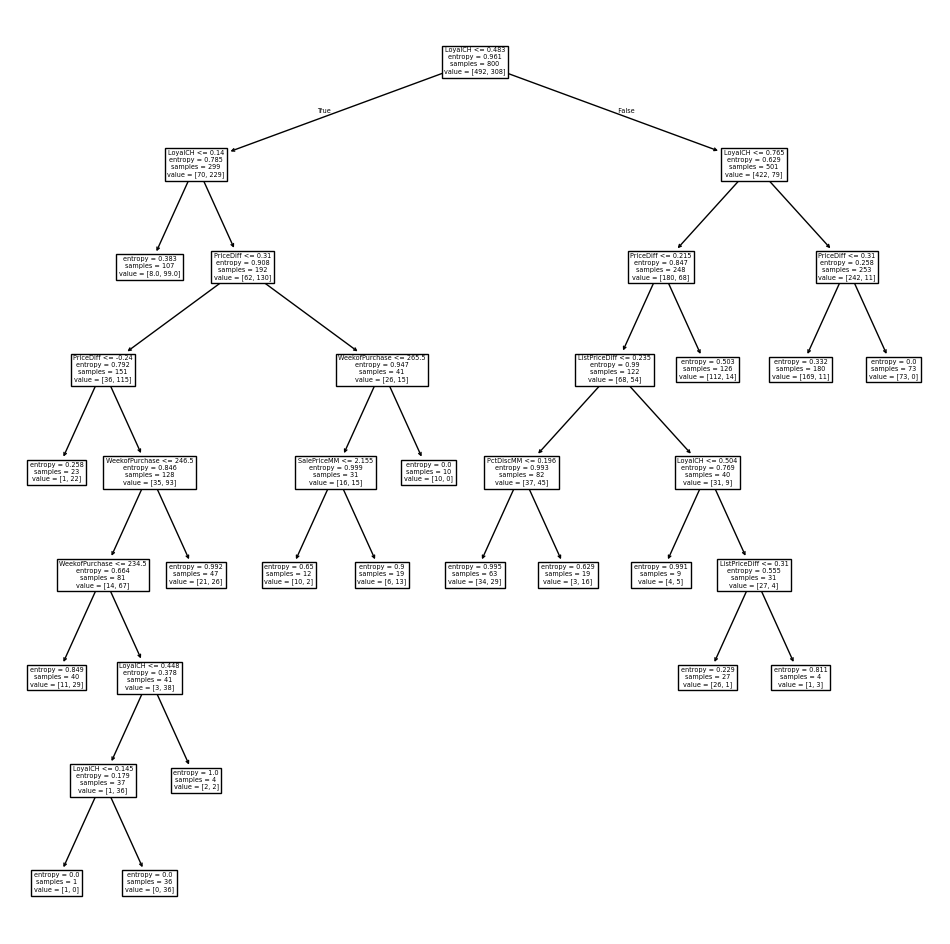

In [122]:
ax = subplots(figsize=(12, 12))[1]
best_ = grid.best_estimator_
plot_tree(best_,
feature_names=feature_names,
ax=ax);

In [123]:
best_.tree_.n_leaves

np.int64(18)

In [125]:
best_.tree_.n_features

17

In [136]:
print(accuracy_score(Y_test,
        best_.predict(X_test)))

confusion = confusion_table(best_.predict(X_test),
                            Y_test)
confusion

0.7962962962962963


Truth,CH,MM
Predicted,,
CH,139,33
MM,22,76


**The optimized model is far smaller than the initial model, with only 17 terminal nodes. Interestingly, this optimized model only performed marginally better than its unoptimized couterpart. I believe this is a result of the class imbalance that was described in part E.**